In [2]:
# If needed, uncomment:
# !pip install xarray netCDF4 h5netcdf matplotlib numpy

import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 6)
plt.rcParams["image.aspect"] = "auto"

In [4]:
file_path = "a_convert_2_nosm.nc"   # <-- change this

if not os.path.exists(file_path):
    raise FileNotFoundError(f"File not found: {file_path}")

# Try common engines in case one fails
ds = None
engines_to_try = [None, "netcdf4", "h5netcdf", "scipy"]

for eng in engines_to_try:
    try:
        if eng is None:
            ds = xr.open_dataset(file_path)
        else:
            ds = xr.open_dataset(file_path, engine=eng)
        print(f"Opened successfully with engine = {eng}")
        break
    except Exception as e:
        print(f"Failed with engine = {eng}: {e}")

if ds is None:
    raise RuntimeError("Could not open dataset with any tried engine.")

ds


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.5 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/opt/anaconda3/lib/python3.11/runpy.py", line 198, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/opt/anaconda3/lib/python3.11/runpy.py", line 88, in _run_code
    exec(code, run_globals)
  File "/opt/anaconda3/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/opt/anaconda3/lib/python3.11/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/opt/anaconda3/lib/python3.11/sit

AttributeError: _ARRAY_API not found

Failed with engine = None: execution of module netCDF4._netCDF4 raised unreported exception
Failed with engine = netcdf4: cannot import name '__netcdf4libversion__' from 'netCDF4._netCDF4' (/opt/anaconda3/lib/python3.11/site-packages/netCDF4/_netCDF4.cpython-311-darwin.so)
Opened successfully with engine = h5netcdf


<xarray.Dataset> Size: 3GB
Dimensions:                        (x: 61, y: 61, phi: 424, eV: 430)
Coordinates: (12/18)
  * x                              (x) float64 488B 2.09e+03 ... 1.91e+03
  * y                              (y) float64 488B 850.0 847.0 ... 673.0 670.0
  * phi                            (phi) float64 3kB -0.3341 -0.3325 ... 0.3341
  * eV                             (eV) float64 3kB -1.497 -1.492 ... 0.517
    long_z                         float64 8B ...
    short_x                        float64 8B ...
    ...                             ...
    alpha                          float64 8B ...
    psi                            float64 8B ...
    physical_long_x                float64 8B ...
    physical_long_y                float64 8B ...
    physical_long_z                float64 8B ...
    z                              float64 8B ...
Data variables:
    __xarray_dataarray_variable__  (x, y, eV, phi) int32 3GB ...

In [6]:
print("=" * 80)
print("DATASET SUMMARY")
print("=" * 80)
print(ds)

print("\n" + "=" * 80)
print("DIMENSIONS")
print("=" * 80)
for dim_name, dim_size in ds.dims.items():
    print(f"{dim_name}: {dim_size}")

print("\n" + "=" * 80)
print("COORDINATES")
print("=" * 80)
for coord_name, coord in ds.coords.items():
    print(f"{coord_name}: shape={coord.shape}, dtype={coord.dtype}")
    if coord.attrs:
        print(f"  attrs={dict(coord.attrs)}")

print("\n" + "=" * 80)
print("DATA VARIABLES")
print("=" * 80)
for var_name, var in ds.data_vars.items():
    print(f"{var_name}: dims={var.dims}, shape={var.shape}, dtype={var.dtype}")
    if var.attrs:
        print(f"  attrs={dict(var.attrs)}")

print("\n" + "=" * 80)
print("GLOBAL ATTRIBUTES / METADATA")
print("=" * 80)
for k, v in ds.attrs.items():
    print(f"{k}: {v}")

DATASET SUMMARY
<xarray.Dataset> Size: 3GB
Dimensions:                        (x: 61, y: 61, phi: 424, eV: 430)
Coordinates: (12/18)
  * x                              (x) float64 488B 2.09e+03 ... 1.91e+03
  * y                              (y) float64 488B 850.0 847.0 ... 673.0 670.0
  * phi                            (phi) float64 3kB -0.3341 -0.3325 ... 0.3341
  * eV                             (eV) float64 3kB -1.497 -1.492 ... 0.517
    long_z                         float64 8B ...
    short_x                        float64 8B ...
    ...                             ...
    alpha                          float64 8B ...
    psi                            float64 8B ...
    physical_long_x                float64 8B ...
    physical_long_y                float64 8B ...
    physical_long_z                float64 8B ...
    z                              float64 8B ...
Data variables:
    __xarray_dataarray_variable__  (x, y, eV, phi) int32 3GB ...

DIMENSIONS
x: 61
y: 61
phi: 424
eV:

/var/folders/xw/t0vmg1w13jdbppbxnr_18tpr0000gn/T/ipykernel_90197/3160651459.py:9: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  for dim_name, dim_size in ds.dims.items():


In [8]:
def inspect_dataset(ds):
    print("=" * 100)
    print("DETAILED VARIABLE INSPECTION")
    print("=" * 100)

    for name in list(ds.coords) + list(ds.data_vars):
        arr = ds[name]
        print(f"\n{name}")
        print("-" * 100)
        print(f"Type      : {'coordinate' if name in ds.coords else 'data_var'}")
        print(f"Dims      : {arr.dims}")
        print(f"Shape     : {arr.shape}")
        print(f"Dtype     : {arr.dtype}")
        print(f"Size      : {arr.size}")
        print(f"Attrs     : {dict(arr.attrs)}")

        try:
            values = arr.values
            if np.issubdtype(values.dtype, np.number):
                finite = np.isfinite(values)
                if finite.any():
                    print(f"Min       : {np.nanmin(values)}")
                    print(f"Max       : {np.nanmax(values)}")
                    print(f"Mean      : {np.nanmean(values)}")
                else:
                    print("All values are non-finite.")
            else:
                flat_preview = values.ravel()[:10]
                print(f"Preview   : {flat_preview}")
        except Exception as e:
            print(f"Could not compute numeric summary: {e}")

inspect_dataset(ds)

DETAILED VARIABLE INSPECTION

x
----------------------------------------------------------------------------------------------------
Type      : coordinate
Dims      : ('x',)
Shape     : (61,)
Dtype     : float64
Size      : 61
Attrs     : {}
Min       : 1910.0
Max       : 2090.0
Mean      : 2000.0

y
----------------------------------------------------------------------------------------------------
Type      : coordinate
Dims      : ('y',)
Shape     : (61,)
Dtype     : float64
Size      : 61
Attrs     : {}
Min       : 670.0
Max       : 850.0
Mean      : 760.0

phi
----------------------------------------------------------------------------------------------------
Type      : coordinate
Dims      : ('phi',)
Shape     : (424,)
Dtype     : float64
Size      : 424
Attrs     : {}
Min       : -0.33406910880110463
Max       : 0.33406910880110463
Mean      : 0.0

eV
----------------------------------------------------------------------------------------------------
Type      : coordinate
Dim

In [10]:
var_info = []

for name, var in ds.data_vars.items():
    var_info.append({
        "name": name,
        "dims": var.dims,
        "shape": var.shape,
        "ndim": var.ndim,
        "size": int(np.prod(var.shape))
    })

var_info = sorted(var_info, key=lambda x: x["size"], reverse=True)

print("Variables sorted by total size:\n")
for item in var_info:
    print(item)

Variables sorted by total size:

{'name': '__xarray_dataarray_variable__', 'dims': ('x', 'y', 'eV', 'phi'), 'shape': (61, 61, 430, 424), 'ndim': 4, 'size': 678412720}


In [12]:
def pick_main_numeric_variable(ds):
    candidates = []
    for name, var in ds.data_vars.items():
        try:
            if np.issubdtype(var.dtype, np.number):
                candidates.append((name, var.size, var.ndim, var))
        except Exception:
            pass

    if not candidates:
        raise ValueError("No numeric data variables found in dataset.")

    # Prefer largest variable
    candidates.sort(key=lambda x: x[1], reverse=True)
    return candidates[0][0]

main_var_name = pick_main_numeric_variable(ds)
main_var = ds[main_var_name]

print(f"Chosen main variable: {main_var_name}")
print(main_var)

Chosen main variable: __xarray_dataarray_variable__
<xarray.DataArray '__xarray_dataarray_variable__' (x: 61, y: 61, eV: 430,
                                                   phi: 424)> Size: 3GB
array([[[[0, ..., 0],
         ...,
         [0, ..., 0]],

        ...,

        [[0, ..., 0],
         ...,
         [0, ..., 0]]],


       ...,


       [[[0, ..., 0],
         ...,
         [0, ..., 0]],

        ...,

        [[0, ..., 0],
         ...,
         [0, ..., 0]]]], shape=(61, 61, 430, 424), dtype=int32)
Coordinates: (12/18)
  * x                (x) float64 488B 2.09e+03 2.087e+03 ... 1.913e+03 1.91e+03
  * y                (y) float64 488B 850.0 847.0 844.0 ... 676.0 673.0 670.0
  * phi              (phi) float64 3kB -0.3341 -0.3325 -0.3309 ... 0.3325 0.3341
  * eV               (eV) float64 3kB -1.497 -1.492 -1.488 ... 0.5123 0.517
    long_z           float64 8B -760.0
    short_x          float64 8B 4.196e-08
    ...               ...
    alpha            float64 8B 1.5

Plotting variable: __xarray_dataarray_variable__
Dims: ('x', 'y', 'eV', 'phi'), shape: (61, 61, 430, 424)


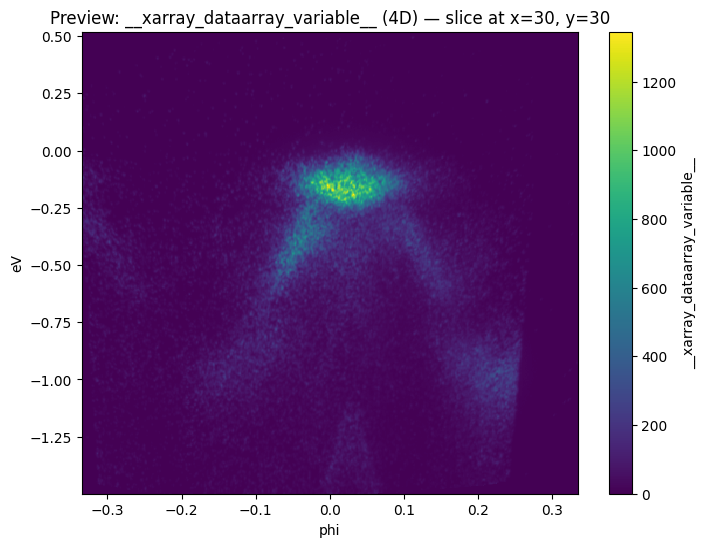

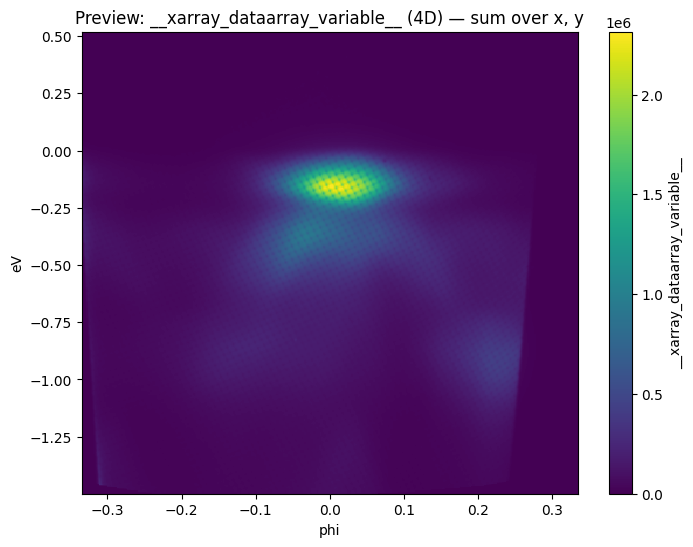

In [14]:
def plot_generic_preview(data_array, title_prefix=""):
    arr = data_array
    print(f"Plotting variable: {arr.name}")
    print(f"Dims: {arr.dims}, shape: {arr.shape}")

    if arr.ndim == 1:
        plt.figure()
        arr.plot()
        plt.title(f"{title_prefix}{arr.name} (1D)")
        plt.show()

    elif arr.ndim == 2:
        plt.figure()
        arr.plot(cmap="viridis")
        plt.title(f"{title_prefix}{arr.name} (2D)")
        plt.show()

    elif arr.ndim == 3:
        # Show middle slice along first axis
        mid0 = arr.shape[0] // 2
        slice2d = arr.isel({arr.dims[0]: mid0})

        plt.figure()
        slice2d.plot(cmap="viridis")
        plt.title(f"{title_prefix}{arr.name} (3D) — middle slice at {arr.dims[0]}={mid0}")
        plt.show()

        # Also show sum projection over first axis
        proj = arr.sum(dim=arr.dims[0], skipna=True)
        plt.figure()
        proj.plot(cmap="viridis")
        plt.title(f"{title_prefix}{arr.name} (3D) — sum over {arr.dims[0]}")
        plt.show()

    elif arr.ndim == 4:
        # Take middle slices in first two dims, leaving last two for image
        mid0 = arr.shape[0] // 2
        mid1 = arr.shape[1] // 2
        slice2d = arr.isel({arr.dims[0]: mid0, arr.dims[1]: mid1})

        plt.figure()
        slice2d.plot(cmap="viridis")
        plt.title(
            f"{title_prefix}{arr.name} (4D) — slice at "
            f"{arr.dims[0]}={mid0}, {arr.dims[1]}={mid1}"
        )
        plt.show()

        # Sum over first two dims
        proj = arr.sum(dim=[arr.dims[0], arr.dims[1]], skipna=True)
        plt.figure()
        proj.plot(cmap="viridis")
        plt.title(
            f"{title_prefix}{arr.name} (4D) — sum over {arr.dims[0]}, {arr.dims[1]}"
        )
        plt.show()

    else:
        print("Data has ndim > 4. Making a reduced 2D projection.")
        reduce_dims = list(arr.dims[:-2])
        proj = arr.sum(dim=reduce_dims, skipna=True)

        plt.figure()
        proj.plot(cmap="viridis")
        plt.title(f"{title_prefix}{arr.name} — reduced projection")
        plt.show()

plot_generic_preview(main_var, title_prefix="Preview: ")

In [16]:
print("=" * 80)
print("COORDINATE RANGES")
print("=" * 80)

for coord_name, coord in ds.coords.items():
    print(f"\n{coord_name}")
    print(f"shape = {coord.shape}, dtype = {coord.dtype}")
    try:
        vals = coord.values
        if np.issubdtype(vals.dtype, np.number) and vals.size > 0:
            print(f"min = {np.nanmin(vals)}")
            print(f"max = {np.nanmax(vals)}")
            print(f"first few = {vals[:10] if vals.ndim == 1 else 'not 1D'}")
        else:
            print(f"preview = {vals[:10] if vals.ndim == 1 else vals}")
    except Exception as e:
        print(f"Could not summarize coordinate: {e}")

COORDINATE RANGES

x
shape = (61,), dtype = float64
min = 1910.0
max = 2090.0
first few = [2090. 2087. 2084. 2081. 2078. 2075. 2072. 2069. 2066. 2063.]

y
shape = (61,), dtype = float64
min = 670.0
max = 850.0
first few = [850. 847. 844. 841. 838. 835. 832. 829. 826. 823.]

phi
shape = (424,), dtype = float64
min = -0.33406910880110463
max = 0.33406910880110463
first few = [-0.33406911 -0.33248959 -0.33091006 -0.32933054 -0.32775102 -0.32617149
 -0.32459197 -0.32301245 -0.32143293 -0.3198534 ]

eV
shape = (430,), dtype = float64
min = -1.497065256
max = 0.5170193879999998
first few = [-1.49706526 -1.49237042 -1.48767558 -1.48298075 -1.47828591 -1.47359108
 -1.46889624 -1.4642014  -1.45950657 -1.45481173]

long_z
shape = (), dtype = float64
min = -760.007
max = -760.007
first few = not 1D

short_x
shape = (), dtype = float64
min = 4.196166992187e-08
max = 4.196166992187e-08
first few = not 1D

short_y
shape = (), dtype = float64
min = -6.820678710937e-06
max = -6.820678710937e-06
first 

Working with dims: ('x', 'y', 'eV', 'phi')


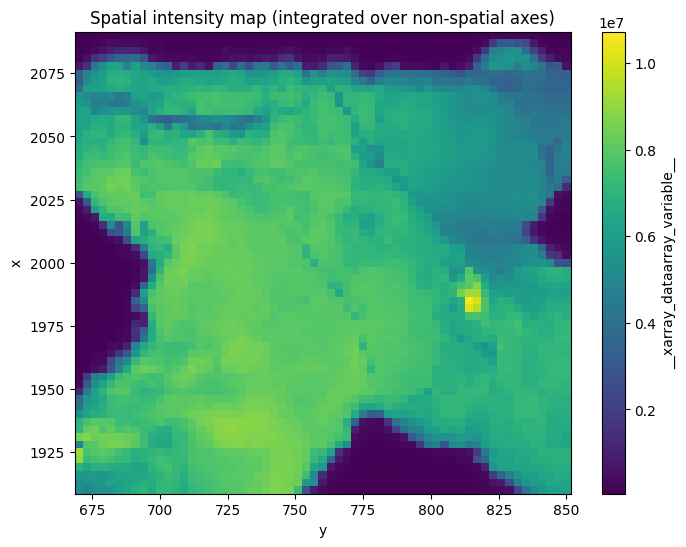

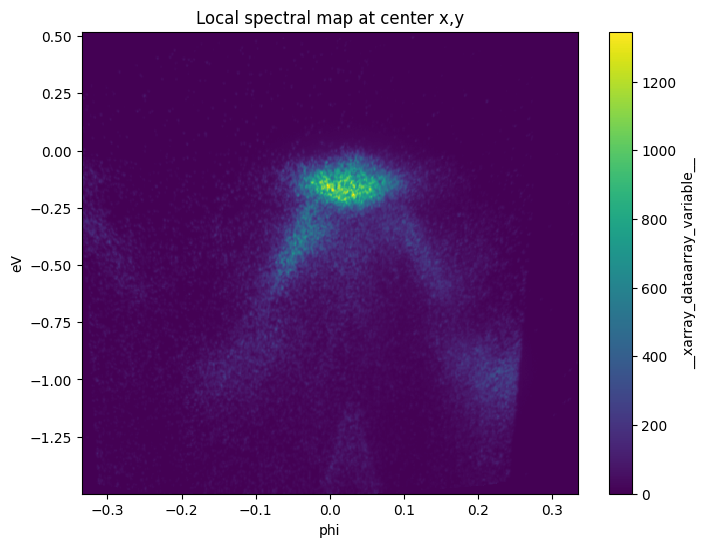

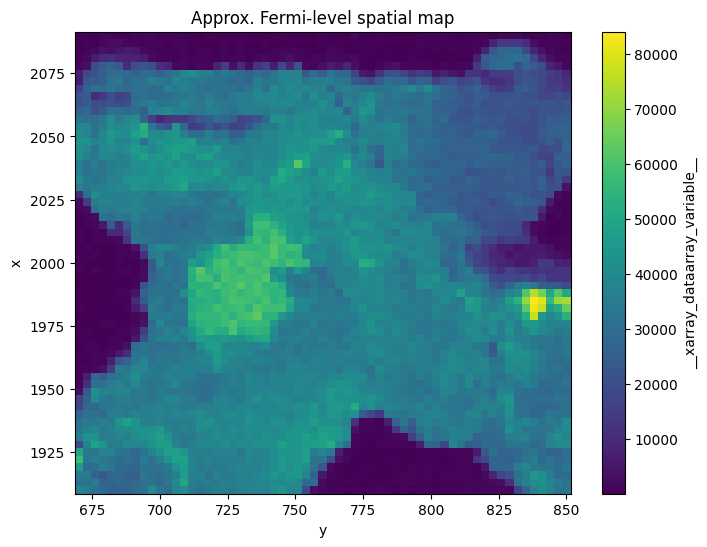

In [18]:
def find_dim_like(dims, keywords):
    dims_lower = {d.lower(): d for d in dims}
    for key in keywords:
        for dlow, dorig in dims_lower.items():
            if key in dlow:
                return dorig
    return None

def nanoarpes_views(arr):
    dims = arr.dims
    print(f"Working with dims: {dims}")

    x_dim  = find_dim_like(dims, ["x"])
    y_dim  = find_dim_like(dims, ["y"])
    e_dim  = find_dim_like(dims, ["energy", "ene", "e"])
    kx_dim = find_dim_like(dims, ["kx"])
    ky_dim = find_dim_like(dims, ["ky"])
    k_dim  = find_dim_like(dims, ["k", "momentum", "angle"])

    # 1. Spatial map by integrating over all non-spatial axes
    if x_dim is not None and y_dim is not None:
        other_dims = [d for d in dims if d not in [x_dim, y_dim]]
        spatial_map = arr.sum(dim=other_dims, skipna=True) if other_dims else arr

        plt.figure()
        spatial_map.plot(cmap="viridis")
        plt.title("Spatial intensity map (integrated over non-spatial axes)")
        plt.show()

    # 2. Energy map or momentum map at middle x,y
    if x_dim is not None and y_dim is not None:
        sel = {
            x_dim: arr.sizes[x_dim] // 2,
            y_dim: arr.sizes[y_dim] // 2
        }
        local_spec = arr.isel(sel)

        if local_spec.ndim == 2:
            plt.figure()
            local_spec.plot(cmap="viridis")
            plt.title("Local spectral map at center x,y")
            plt.show()
        elif local_spec.ndim == 1:
            plt.figure()
            local_spec.plot()
            plt.title("Local spectrum at center x,y")
            plt.show()

    # 3. Energy-integrated map near Fermi level if energy axis exists
    if x_dim is not None and y_dim is not None and e_dim is not None:
        try:
            ecoord = arr[e_dim]
            e_vals = ecoord.values

            # Choose energies closest to 0 if already Fermi corrected
            idx_sorted = np.argsort(np.abs(e_vals))
            n_pick = min(5, len(idx_sorted))
            selected = idx_sorted[:n_pick]

            ef_map = arr.isel({e_dim: selected}).sum(dim=e_dim, skipna=True)

            other_dims = [d for d in ef_map.dims if d not in [x_dim, y_dim]]
            if other_dims:
                ef_map = ef_map.sum(dim=other_dims, skipna=True)

            plt.figure()
            ef_map.plot(cmap="viridis")
            plt.title("Approx. Fermi-level spatial map")
            plt.show()
        except Exception as e:
            print(f"Could not make Fermi-level map: {e}")

nanoarpes_views(main_var)

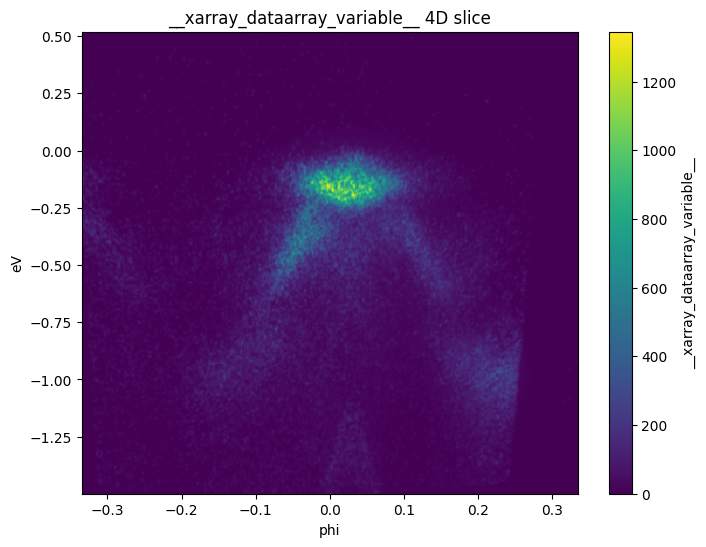

Saved: nc_previews/__xarray_dataarray_variable___4d_slice.png


In [20]:
output_dir = "nc_previews"
os.makedirs(output_dir, exist_ok=True)

def save_basic_previews(arr, output_dir="nc_previews"):
    if arr.ndim == 2:
        plt.figure()
        arr.plot(cmap="viridis")
        plt.title(f"{arr.name} (2D)")
        out = os.path.join(output_dir, f"{arr.name}_2d_preview.png")
        plt.savefig(out, dpi=200, bbox_inches="tight")
        plt.show()
        print(f"Saved: {out}")

    elif arr.ndim == 3:
        mid0 = arr.shape[0] // 2
        slice2d = arr.isel({arr.dims[0]: mid0})
        plt.figure()
        slice2d.plot(cmap="viridis")
        plt.title(f"{arr.name} middle slice")
        out = os.path.join(output_dir, f"{arr.name}_3d_slice.png")
        plt.savefig(out, dpi=200, bbox_inches="tight")
        plt.show()
        print(f"Saved: {out}")

        proj = arr.sum(dim=arr.dims[0], skipna=True)
        plt.figure()
        proj.plot(cmap="viridis")
        plt.title(f"{arr.name} projection")
        out = os.path.join(output_dir, f"{arr.name}_3d_projection.png")
        plt.savefig(out, dpi=200, bbox_inches="tight")
        plt.show()
        print(f"Saved: {out}")

    elif arr.ndim == 4:
        mid0 = arr.shape[0] // 2
        mid1 = arr.shape[1] // 2
        slice2d = arr.isel({arr.dims[0]: mid0, arr.dims[1]: mid1})
        plt.figure()
        slice2d.plot(cmap="viridis")
        plt.title(f"{arr.name} 4D slice")
        out = os.path.join(output_dir, f"{arr.name}_4d_slice.png")
        plt.savefig(out, dpi=200, bbox_inches="tight")
        plt.show()
        print(f"Saved: {out}")

save_basic_previews(main_var, output_dir=output_dir)